# Olist Route-Level EDA

This notebook focuses on the route dimension of the late-delivery problem: the origin-destination pair defined by seller state and customer state. Iteration-2 error analysis showed that `primary_seller_state` was the second most important feature after `estimated_delivery_days`, so there is almost certainly geographic structure worth understanding before adding more sophisticated features.

A caveat up front: the route here is an **order-level approximation**, not shipment-level ground truth. `primary_seller_state` is a mode-based summary, so multi-seller orders are collapsed to one seller state.

Questions:

1. Which state-to-state corridors have the highest late rates?
2. Are long-distance corridors systematically worse, or is the pattern lumpy?
3. Does the `seller_customer_same_state` shortcut feature capture most of the signal, or is inter-state variation finer than that?

**Out of scope for now.** Haversine distances from the Olist geolocation table are a planned follow-up. The stub at the end of the notebook records the design.

In [8]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data.io import load_olist_tables
from src.data.prepare import build_modeling_frame
from src.features.engineering import build_model_dataset

sns.set_theme(style='whitegrid')

tables = load_olist_tables(ROOT / 'data' / 'raw')
modeling_frame = build_modeling_frame(tables)
dataset = build_model_dataset(modeling_frame)
print(f'Rows: {len(dataset):,}')
print(f'Baseline late rate: {dataset["is_late"].mean():.2%}')

Rows: 96,470
Baseline late rate: 8.11%


## 1. Corridor volume and late rate

Build a contingency table over `(primary_seller_state, customer_state)` with both order counts and late rates. The volume view tells us which corridors are statistically meaningful; the rate view is only trustworthy where volume is high.

In [9]:
MIN_CORRIDOR_ORDERS = 50

route_stats = (
    dataset.groupby(['primary_seller_state', 'customer_state'])
    .agg(orders=('is_late', 'size'), late_rate=('is_late', 'mean'))
    .reset_index()
)
route_stats['is_same_state'] = route_stats['primary_seller_state'] == route_stats['customer_state']
print(f'Distinct corridors: {len(route_stats):,}')
print(f'Corridors with >= {MIN_CORRIDOR_ORDERS} orders: {(route_stats["orders"] >= MIN_CORRIDOR_ORDERS).sum()}')
route_stats.sort_values('orders', ascending=False).head(10)

Distinct corridors: 411
Corridors with >= 50 orders: 100


,primary_seller_state,customer_state,orders,late_rate,is_same_state
409,SP,SP,30671,0.062339,True
402,SP,RJ,8137,0.155340,False
394,SP,MG,7417,0.063503,False
406,SP,RS,3585,0.076151,False
401,SP,PR,3113,0.053646,False
277,PR,SP,2944,0.035326,False
169,MG,SP,2566,0.042868,False
407,SP,SC,2325,0.110108,False
388,SP,BA,2304,0.149740,False
154,MG,MG,1537,0.031880,True


## 2. Late-rate heatmap

Restrict to corridors with enough volume to be trustworthy, then pivot into a heatmap. Cells with fewer than the volume threshold are masked.

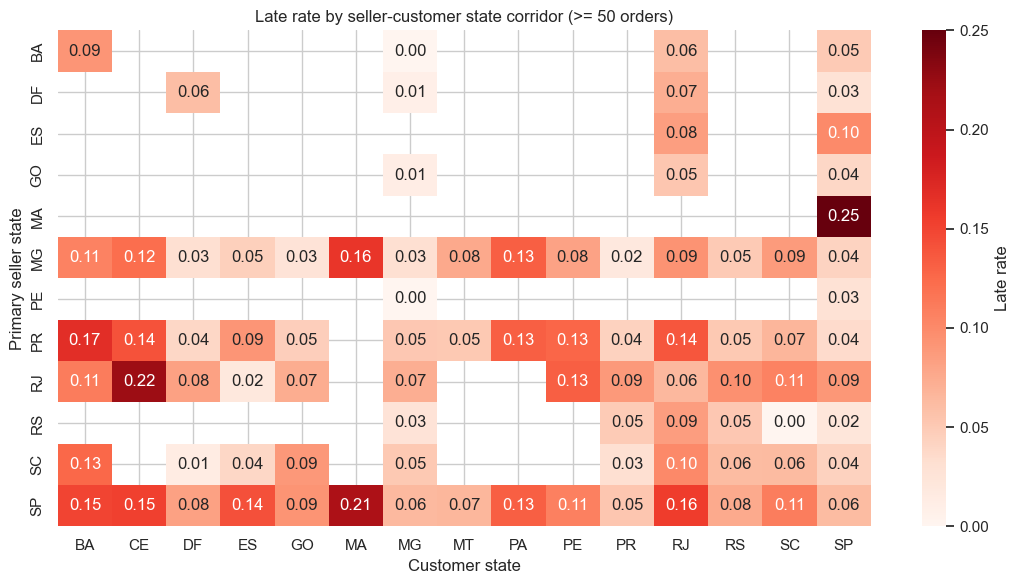

In [10]:
volume_pivot = route_stats.pivot(
    index='primary_seller_state', columns='customer_state', values='orders'
).fillna(0)
rate_pivot = route_stats.pivot(
    index='primary_seller_state', columns='customer_state', values='late_rate'
)

mask = volume_pivot < MIN_CORRIDOR_ORDERS
top_states = (
    route_stats.groupby('primary_seller_state')['orders'].sum().sort_values(ascending=False).head(12).index
)
top_customers = (
    route_stats.groupby('customer_state')['orders'].sum().sort_values(ascending=False).head(15).index
)
rate_sub = rate_pivot.loc[rate_pivot.index.intersection(top_states), rate_pivot.columns.intersection(top_customers)]
mask_sub = mask.loc[rate_sub.index, rate_sub.columns]

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(
    rate_sub,
    mask=mask_sub,
    cmap='Reds',
    annot=True,
    fmt='.2f',
    cbar_kws={'label': 'Late rate'},
    ax=ax,
)
ax.set_title(f'Late rate by seller-customer state corridor (>= {MIN_CORRIDOR_ORDERS} orders)')
ax.set_xlabel('Customer state')
ax.set_ylabel('Primary seller state')
plt.tight_layout()
plt.show()

## 3. Riskiest and safest corridors

Rank corridors with enough volume so the ordering is not dominated by noise from two or three bad orders. With `MIN_CORRIDOR_ORDERS = 50`, these tables are still exploratory: interpret them as directional evidence, especially when a corridor's late rate is based on only a few dozen orders.

In [11]:
viable = route_stats[route_stats['orders'] >= MIN_CORRIDOR_ORDERS].copy()
viable['lift_vs_base'] = viable['late_rate'] / dataset['is_late'].mean()
riskiest = viable.sort_values('late_rate', ascending=False).head(15)
riskiest

,primary_seller_state,customer_state,orders,late_rate,is_same_state,lift_vs_base
385,SP,AL,255,0.262745,False,3.238822
142,MA,SP,124,0.250000,False,3.081715
284,RJ,CE,54,0.222222,False,2.739302
393,SP,MA,491,0.211813,False,2.610984
400,SP,PI,329,0.182371,False,2.248059
256,PR,BA,143,0.167832,False,2.068843
408,SP,SE,207,0.164251,False,2.024702
153,MG,MA,62,0.161290,False,1.988203
402,SP,RJ,8137,0.155340,False,1.914852
389,SP,CE,968,0.152893,False,1.884685


In [12]:
safest = viable.sort_values('late_rate').head(15)
safest

,primary_seller_state,customer_state,orders,late_rate,is_same_state,lift_vs_base
13,BA,MG,51,0.000000,False,0.000000
228,PE,MG,62,0.000000,False,0.000000
347,RS,SC,116,0.000000,False,0.000000
60,DF,MG,103,0.009709,False,0.119678
104,GO,MG,83,0.012048,False,0.148516
357,SC,DF,69,0.014493,False,0.178650
161,MG,PR,365,0.019178,False,0.236406
286,RJ,ES,99,0.020202,False,0.249027
349,RS,SP,667,0.022489,False,0.277216
152,MG,GO,151,0.026490,False,0.326539


## 4. Does the `seller_customer_same_state` shortcut capture it?

The existing feature set has a binary flag for same-state routes. If inter-state routes are uniformly worse, that flag captures most of the geographic signal; if there is strong variation *within* inter-state routes, the flag is too coarse and route-level features (corridor target encoding, distance) would add value.

Because the route is defined from `primary_seller_state`, the conclusion here should be read as an order-level proxy rather than a shipment-level logistics result.

In [13]:
same_state_summary = (
    dataset.groupby('seller_customer_same_state')['is_late']
    .agg(['size', 'mean'])
    .rename(columns={'size': 'orders', 'mean': 'late_rate'})
)
same_state_summary

,orders,late_rate
seller_customer_same_state,,
0,61818,0.092562
1,34652,0.060718


In [ ]:
inter_state = viable[~viable['is_same_state']]
print('Inter-state corridor late rates (volume-weighted std is the relevant spread):')
print(f'  min:   {inter_state["late_rate"].min():.3f}')
print(f'  max:   {inter_state["late_rate"].max():.3f}')
weighted_mean = (inter_state['late_rate'] * inter_state['orders']).sum() / inter_state['orders'].sum()
weighted_var = (
    ((inter_state['late_rate'] - weighted_mean) ** 2 * inter_state['orders']).sum()
    / inter_state['orders'].sum()
)
print(f'  vol-weighted mean: {weighted_mean:.3f}')
print(f'  vol-weighted std:  {weighted_var ** 0.5:.3f}')

## Route takeaway

- Geography matters beyond a simple same-state flag: inter-state corridors show meaningful late-rate dispersion even after restricting to higher-volume corridors.
- The corridor tables are exploratory because the route uses `primary_seller_state`, a mode-based proxy for orders with potentially multiple sellers.
- The next feature to test is seller-customer distance from the geolocation table, ideally alongside corridor or seller-history features.
- The lowest-late-rate corridors should be interpreted cautiously: a zero-late corridor with only a few dozen orders is more of a clue than a stable operational fact.

## 5. Follow-up: seller-customer distance from the geolocation table

Planned extension (not implemented yet):

1. Load `olist_geolocation_dataset.csv` and average lat/lon by `geolocation_zip_code_prefix`.
2. Map each `customer_zip_code_prefix` and `seller_zip_code_prefix` to a centroid.
3. Compute a haversine distance per order at the seller-customer level.
4. Aggregate to the order level (mean distance across sellers for split-seller orders) and add as a numeric feature.
5. Test whether distance beats or complements `primary_seller_state` and `seller_customer_same_state` in permutation importance.

The geolocation table is noisy (multiple centroids per prefix, some obvious typos), so the loader for this feature should clip to a reasonable Brazil bounding box before averaging. Adding this feature belongs in `src/features/engineering.py`, not in the notebook.